CONTENTS:
- [**Exploratory Data Analysis: Gridstatus metadata**](#**exploratory-data-analysis:-gridstatus-metadata**)
    - [**Missing Value Summary**](#**missing-value-summary**)
      - [**Exploring Gaps in Metadata Coverage**](#**exploring-gaps-in-metadata-coverage**)
    - [**Exploratory Analysis**](#**exploratory-analysis**)
      - [****1. Source Distribution****](#****1.-source-distribution****)
      - [****2. Frequency Distribution****](#****2.-frequency-distribution****)
      - [****3. How far the data goes back****](#****3.-how-far-the-data-goes-back****)
      - [****4. Dataset Coverage Distribution****](#****4.-dataset-coverage-distribution****)
      - [****5. Coverage Insights by Frequency and Snowflake Ingestion****](#****5.-coverage-insights-by-frequency-and-snowflake-ingestion****)
      - [****6. Snowflake Ingestion Insights by Table Type****](#****6.-snowflake-ingestion-insights-by-table-type****)
      - [****7. Analysis of Potentially Discontinued Series****](#****7.-analysis-of-potentially-discontinued-series****)
      - [****8. Coverage by Source and Category****](#****8.-coverage-by-source-and-category****)

<a name='**exploratory-data-analysis:-gridstatus-metadata**'></a>
# **Exploratory Data Analysis: Gridstatus metadata**

This notebook analyzes the metadata of 268 time series datasets available on [GridStatus.io](https://www.gridstatus.io/datasets). The metadata is loaded from the AWS S3 bucket `causify-data-collaborators` using helper functions from `hs3.py`. The goal is to explore the variety, coverage, and quality of the available time series data.

In [19]:
# Import necessary libraries and modules.
import io

import helpers.hs3 as hs3
import IPython.display as disp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [20]:
# Read metadata from the S3 bucket.
file_path = "s3://causify-data-collaborators/causal_automl/metadata/gridstatus_metadata.csv"
file = hs3.from_file(file_path, aws_profile="ck")
gs_meta = pd.read_csv(io.StringIO(file))

In [21]:
print(gs_meta.shape)
print(gs_meta.columns)
disp.display(gs_meta.head())

(268, 19)
Index(['id', 'name', 'description', 'earliest_available_time_utc',
       'latest_available_time_utc', 'source', 'last_checked_time_utc',
       'primary_key_columns', 'publish_time_column', 'time_index_column',
       'subseries_index_column', 'all_columns', 'number_of_rows_approximate',
       'table_type', 'is_in_snowflake', 'data_frequency', 'source_url',
       'publication_frequency', 'is_published'],
      dtype='object')


,id,name,description,earliest_available_time_utc,latest_available_time_utc,source,last_checked_time_utc,primary_key_columns,publish_time_column,time_index_column,subseries_index_column,all_columns,number_of_rows_approximate,table_type,is_in_snowflake,data_frequency,source_url,publication_frequency,is_published
0,all_records,All Records,Top daily records for various metrics across a...,2017-12-13T22:05:00+00:00,2025-03-26T15:30:00+00:00,gridstatus,2025-04-09T15:37:14+00:00,"['iso', 'rank', 'record_type', 'metric_name']",NaN,interval_start_utc,NaN,"[{'name': 'rank', 'type': 'BIGINT', 'is_numeri...",620,materialized_view,False,IRREGULAR,NaN,NaN,True
1,all_records_timeseries,All Records Timeseries,Timeline of new records for various metrics in...,2011-01-01T06:30:00+00:00,2025-03-25T00:40:00+00:00,gridstatus,2025-04-09T15:37:14+00:00,"['iso', 'interval_start_utc', 'record_type', '...",NaN,interval_start_utc,NaN,"[{'name': 'iso', 'type': 'TEXT', 'is_numeric':...",2076,materialized_view,False,IRREGULAR,NaN,NaN,True
2,caiso_as_prices,CAISO AS Prices,Ancillary Services Prices as reported by CAISO...,2010-01-01T08:00:00+00:00,2025-04-10T06:00:00+00:00,caiso,2025-04-09T15:37:12+00:00,"['interval_start_utc', 'region', 'market']",NaN,interval_start_utc,region,"[{'name': 'interval_start_utc', 'type': 'TIMES...",621445,table,True,1_HOUR,http://oasis.caiso.com/mrioasis/logon.do,NaN,True
3,caiso_as_procurement_dam,CAISO AS Procurement DAM,Ancillary services procurement data from CAISO...,2010-01-01T08:00:00+00:00,2025-04-10T06:00:00+00:00,caiso,2025-04-09T15:37:17+00:00,"['interval_start_utc', 'region']",NaN,interval_start_utc,region,"[{'name': 'interval_start_utc', 'type': 'TIMES...",623449,table,True,1_HOUR,http://oasis.caiso.com/mrioasis/logon.do,NaN,True
4,caiso_curtailed_non_operational_generator_report,CAISO Curtailed Non Operational Generator Report,Prior Day Curtailed Non-Operational Generator ...,2021-06-18T07:00:00+00:00,2025-04-09T07:00:00+00:00,caiso,2025-04-09T15:37:31+00:00,"['publish_time_utc', 'outage_mrid', 'curtailme...",publish_time_utc,curtailment_start_time_utc,NaN,"[{'name': 'publish_time_utc', 'type': 'TIMESTA...",2490715,table,True,IRREGULAR,https://www.caiso.com/market-operations/outage...,NaN,True


In [22]:
# Helper function to create plot.
def _make_plots(
    title=None,
    x_label=None,
    y_label=None,
    legend=None,
    x_rotation=None,
    y_rotation=None,
    grid=False,
):
    if title:
        plt.title(title)
    if x_label:
        plt.xlabel(x_label)
    if y_label:
        plt.ylabel(y_label)
    if legend:
        plt.legend(title=legend)
    if x_rotation is not None:
        plt.xticks(rotation=x_rotation)
    if y_rotation is not None:
        plt.yticks(rotation=y_rotation)
    if grid:
        plt.grid(grid)
    plt.show()

In [23]:
# Add a new category by parsing the description to match common categories.
def categorize_metadata(description):
    description = str(description).lower()
    if "load" in description or "demand" in description:
        return "Energy Load"
    elif "price" in description or "lmp" in description:
        return "Prices"
    elif "fuel" in description or "energy source" in description:
        return "Fuel Mix"
    elif "record" in description or "stat" in description:
        return "Records"
    elif (
        "renewable" in description
        or "solar" in description
        or "wind" in description
    ):
        return "Renewables"
    elif (
        "congestion" in description
        or "constraint" in description
        or "interface" in description
    ):
        return "Congestion"
    elif "record" in description or "stat" in description:
        return "Records"
    else:
        return "Other"


gs_meta["category"] = gs_meta["description"].apply(categorize_metadata)

<a name='**missing-value-summary**'></a>
### **Missing Value Summary**

The table below shows the number of missing (null) values in each metadata field, helping identify potential data quality issues.

In [24]:
# Display missing metadata statistics.
missing_count = gs_meta.isna().sum().sort_values(ascending=False)
missing_percent = (
    (gs_meta.isna().mean() * 100).sort_values(ascending=False).round(2)
)
missing_gs_meta = pd.DataFrame(
    {"Missing Count": missing_count, "Missing %": missing_percent}
)
missing_gs_meta = missing_gs_meta[missing_gs_meta["Missing Count"] > 0]
disp.display(missing_gs_meta)

,Missing Count,Missing %
publication_frequency,267,99.63
publish_time_column,198,73.88
subseries_index_column,161,60.07
source_url,37,13.81
earliest_available_time_utc,10,3.73
latest_available_time_utc,10,3.73
last_checked_time_utc,9,3.36
time_index_column,8,2.99
table_type,4,1.49
data_frequency,2,0.75


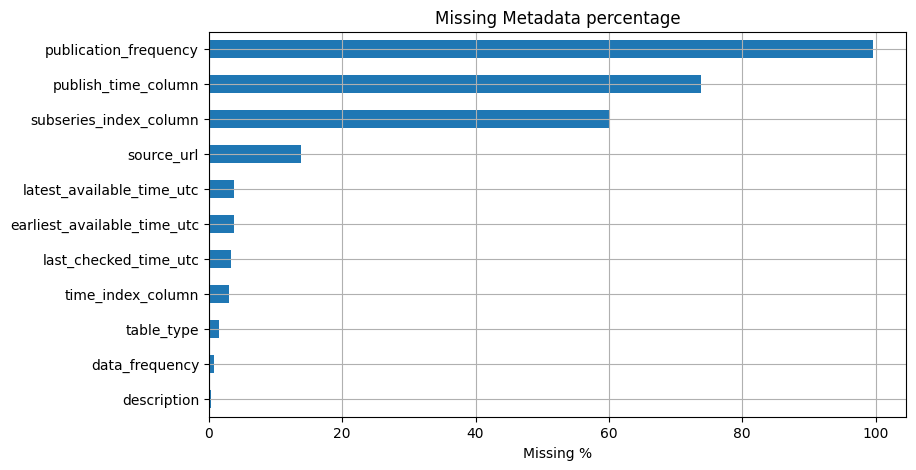

In [25]:
# Plot missing metadata statistics.
missing_gs_meta[missing_gs_meta["Missing Count"] > 0].sort_values(
    "Missing %", ascending=True
)["Missing %"].plot(
    kind="barh", figsize=(9, 5), title="Missing Metadata percentage"
)
_make_plots(x_label="Missing %", grid=True)

<a name='**exploring-gaps-in-metadata-coverage**'></a>
#### **Exploring Gaps in Metadata Coverage**

Metadata gaps often arise due to differences in dataset structures, ingestion processes, and metadata governance practices. The presence of missing values in specific fields may indicate variations in how datasets are sourced, updated, and cataloged. Some fields may be absent due to inconsistencies in data collection methods, while others might reflect evolving metadata standards or incomplete historical ingestion. Understanding these gaps helps assess the completeness and reliability of the dataset catalog, ensuring that metadata accurately supports downstream analytics and decision-making.

Below, we analyze each missing metadata field, identifying potential causes based on operational workflows, structural dataset differences, and system design limitations.


- **publication_frequency (99.63% missing):**
The extremely high gap suggests that publication frequency is either not systematically captured or not applicable for the majority of datasets. Many datasets may be event-driven, updated irregularly, or inherited from external sources without explicit publication schedules. Additionally, this field could have been added later in the metadata schema evolution, leading to historical datasets lacking backfilled values. This points to a potential mismatch between metadata design and the operational characteristics of the data.
- **publish_time_column (73.88% missing):**
A high level of missingness here likely reflects inconsistency in how datasets are released or updated. Some datasets may not have a specific "publish time" because they are refreshed continuously, processed in asynchronous batches, or lack clear publishing events. This suggests that the metadata field assumes a uniform publishing model that does not hold true across diverse data pipelines.
- **subseries_index_column (60.07% missing):**
The absence of subseries indexing for a majority of datasets implies that many datasets are designed without intrinsic hierarchical or grouped structures. Only complex, multi-dimensional datasets would logically require a subseries index. This suggests that the current metadata framework may over-generalize structural features, applying fields that are irrelevant for a large portion of simpler datasets.
- **source_url (13.81% missing):**
Missing source URLs likely reflect the use of internal, proprietary, or third-party licensed data that does not have a publicly accessible web location. It also suggests that documentation standards vary across data ingestion processes, with some sources being better curated than others. This inconsistency may complicate efforts to trace data lineage and verify external authenticity.
- **earliest_available_time_utc (3.73% missing):**
The absence of earliest available timestamps for a small portion of datasets suggests incomplete historical loading during ingestion. Datasets may have been brought into the system focusing primarily on current or active data, without reconstructing full historical timelines. This limits the ability to perform long-term trend analysis for these sources.
- **latest_available_time_utc (3.73% missing):**
Similar missingness in latest timestamps suggests datasets that are either open-ended (still actively updated) or incompletely loaded. It could also reflect ingestion workflows that prioritize initial ingestion without systematically capturing ongoing updates or setting clear update boundaries.
- **last_checked_time_utc (3.36% missing):**
Missing validation timestamps suggest that quality assurance processes are either periodic, resource-constrained, or selectively applied based on dataset importance. This could imply a prioritization strategy where not all datasets are monitored equally, raising potential risks for unnoticed data staleness or degradation.
- **time_index_column (2.99% missing):**
The few datasets missing a time index column may be structured differently — for example, they might represent static reference tables, event logs, or batch snapshots without a clear, continuous time series. Their existence indicates that not all ingested datasets conform to the expected time series model underlying most of the metadata.
- **table_type (1.49% missing):**
A small amount of missingness here suggests occasional gaps during dataset registration, possibly due to manual errors, evolving classification schemes, or onboarding of experimental datasets before full metadata assignment. It highlights that although the metadata process is mostly mature, some edge cases slip through.
- **data_frequency (0.75% missing):**
Where missing, data frequency is likely undefined because updates occur irregularly or opportunistically (e.g., on-demand reporting, event-driven datasets). This suggests that not all datasets support assumptions about consistent periodic updates, and analytical models using frequency information should account for this.
- **description (0.37% missing):**
The very low missingness in descriptions likely results from simple human oversight rather than systemic metadata issues. However, even minor gaps can reduce usability for data discovery and should be addressed to ensure 100% metadata completeness.

<a name='**exploratory-analysis**'></a>
### **Exploratory Analysis**

From the 19 columns available in the GridStatus metadata, the following are most relevant for initial exploratory analysis:

- `source` : Identifies the origin of each dataset.
- `data_frequency` : Describes the granularity of data (e.g. 5 minutes, 1 hour, 1 day, etc).
- `is_in_snowflake` : Indicates whether the dataset is already ingested into the internal Snowflake warehouse.
- `table_type` : Helps categorize datasets by their structure or intended purpose (table, view, materialized view).
- `earliest_available_time_utc` : Indicates the starting point of data availability for each dataset.
- `latest_available_time_utc` : Indicates the most recent timestamp available in each dataset.


Several other metadata fields are available but were excluded from the initial analysis for the following reasons:

- Columns like `id`, `name`, and `description` are identifiers or unstructured text, making them unsuitable for analysis.
- Fields like `primary_key_columns`, `publish_time_column`, `subseries_index_column`, and `all_columns` are helpful for database structure but not very useful for analyzing overall metadata patterns.
- Fields like `last_checked_time_utc` are useful for monitoring and tracking system activity.
- `source_url` is a similar to `source`, as it includes a direct link to the data source, but it contains some null values and may not always be available.
- `number_of_rows_approximate` can be leveraged in future analytical processes to perform dataset size comparisons, enabling scalability assessments and optimization strategies.
- `time_index_column` indicates the name of the column containing timestamps, making it useful for dataset structure but not for actual time-based analysis.
- `is_published` is consistently `True` for all records (unless the metadata is updated) and therefore not relevant for analysis.
- `publication_frequency` is null for all records except one, and as a result, it is excluded from the analysis.

<a name='****1.-source-distribution****'></a>
#### ****1. Source Distribution****

Most of the datasets come from ERCOT, PJM, and CAISO, which are some of the most active and prominent grid operators in North America. Together, they account for over half of all datasets. This dominance can be attributed to several key factors: these operators are technologically advanced, offering consistent, high-quality data crucial for grid operations. Their robust infrastructure, strong regulatory frameworks, and comprehensive real-time monitoring systems enable reliable data streams. As a result, these sources are prioritized due to their ability to provide the most accurate, up-to-date, and complete information for grid stability and market analysis.

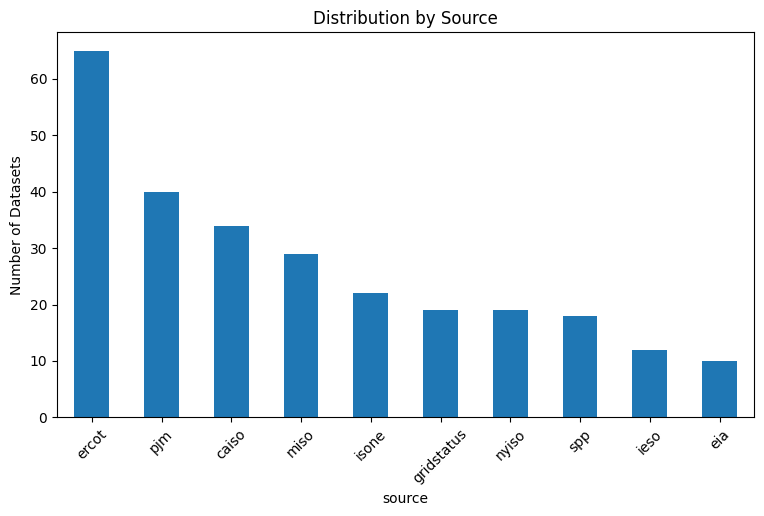

In [26]:
# Plot the distribution of entries by source from the dataframe.
gs_meta["source"].value_counts().plot(kind="bar", figsize=(9, 5))
_make_plots(
    title="Distribution by Source", y_label="Number of Datasets", x_rotation=45
)

<a name='****2.-frequency-distribution****'></a>
#### ****2. Frequency Distribution****

Most datasets in GridStatus are updated frequently, with the majority updating on an hourly basis or every 5 minutes. This indicates a system designed to prioritize real-time or near-real-time data, which is likely crucial for applications requiring timely insights or rapid decision-making. The frequent updates suggest that GridStatus is optimized for scenarios where data freshness is critical, such as monitoring, forecasting, or dynamic reporting. However, fewer datasets with more specialized or less frequent update intervals point to a more selective approach for data that doesn't require constant refreshing. This could reflect a design choice to balance system resources and avoid unnecessary processing for data that doesn’t change frequently.

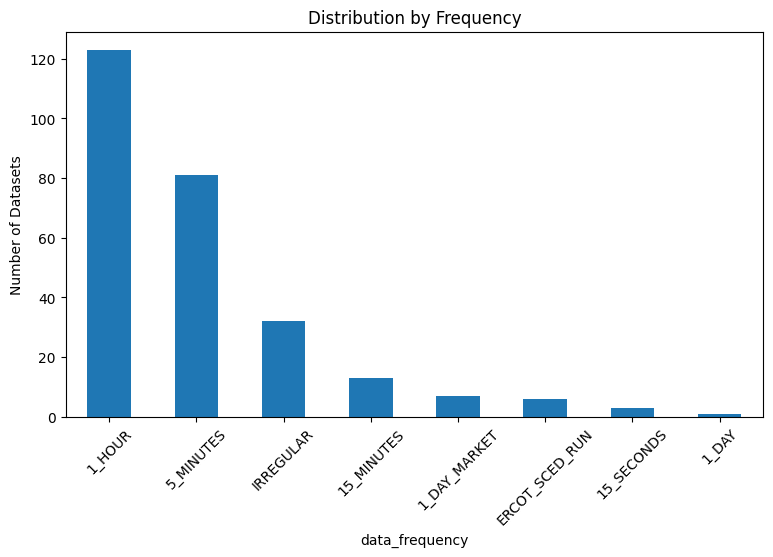

In [27]:
# Plot the distribution of entries by frequency from the dataframe.
gs_meta["data_frequency"].value_counts().plot(kind="bar", figsize=(9, 5))
_make_plots(
    title="Distribution by Frequency", y_label="Number of Datasets", x_rotation=45
)

<a name='****3.-how-far-the-data-goes-back****'></a>
#### ****3. How far the data goes back****

The earliest available datasets indicate a few sources with historical data dating back to 1993 and the early 2000s, suggesting the presence of long-term historical records. However, the majority of datasets begin around 2010 or later, with a noticeable drop in availability after 2020. This gap could be attributed to several factors: a reduction in new data collection, shifts in collection focus, or adjustments in data processing methodologies. The dip in 2020 could also be a result of the global impact of COVID-19, potentially disrupting data collection efforts or shifting priorities during the pandemic. As organizations focused on the immediate needs of the crisis, some data streams may have been paused or limited. Overall, while the bulk of data covers the last decade, the 2020 gap suggests disruptions in normal data collection, possibly compounded by the pandemic.

In [28]:
# Convert timestamps to DateTime format.
gs_meta["earliest_available_time_utc"] = pd.to_datetime(
    gs_meta["earliest_available_time_utc"]
)
gs_meta["latest_available_time_utc"] = pd.to_datetime(
    gs_meta["latest_available_time_utc"]
)

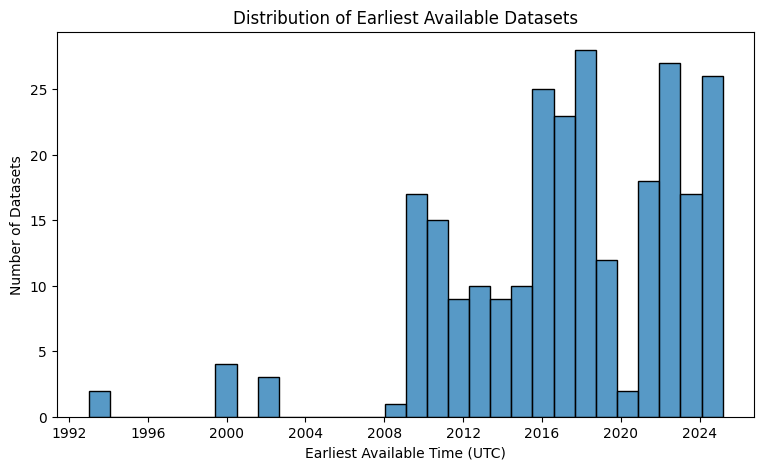

In [29]:
# Plot a histogram of the earliest available datasets.
plt.figure(figsize=(9, 5))
sns.histplot(gs_meta["earliest_available_time_utc"].dropna(), bins=30, kde=False)
_make_plots(
    title="Distribution of Earliest Available Datasets",
    x_label="Earliest Available Time (UTC)",
    y_label="Number of Datasets",
)

In [30]:
# Display the dataset(s) with the earliest available time.
earliest_rows = gs_meta[
    gs_meta["earliest_available_time_utc"]
    == gs_meta["earliest_available_time_utc"].min()
]
print("Earliest available dataset(s):")
disp.display(earliest_rows)

Earliest available dataset(s):


,id,name,description,earliest_available_time_utc,latest_available_time_utc,source,last_checked_time_utc,primary_key_columns,publish_time_column,time_index_column,subseries_index_column,all_columns,number_of_rows_approximate,table_type,is_in_snowflake,data_frequency,source_url,publication_frequency,is_published,category
222,pjm_load_metered_hourly,PJM Load Metered Hourly,The MWh net energy consumption by each service...,1993-01-01 05:00:00+00:00,2025-04-08 03:00:00+00:00,pjm,2025-04-09T15:38:01+00:00,"['interval_start_utc', 'mkt_region', 'zone', '...",NaN,interval_start_utc,load_area,"[{'name': 'interval_start_utc', 'type': 'TIMES...",5681485,table,True,1_HOUR,https://dataminer2.pjm.com/feed/hrl_load_meter...,NaN,True,Energy Load


<a name='****4.-dataset-coverage-distribution****'></a>
#### ****4. Dataset Coverage Distribution****

The distribution of dataset coverage exhibits a multimodal pattern, with the Kernel Density Estimate (KDE) curve peaking around 8-10 years, indicating that most datasets provide medium-term historical coverage. This suggests that a significant portion of datasets may be tied to medium-term projects or have data collection timelines that span 8-10 years, possibly reflecting the average life cycle of many ongoing research or operational datasets. The concentration around 3 years reflects a notable group of datasets with shorter historical coverage. This could indicate datasets that are collected for specific, short-term projects or those with a more limited scope in terms of time. It may also reflect the prevalence of datasets that are updated periodically or on an as-needed basis, which often have a narrower window of coverage. The gap observed after 14-15 years indicates fewer datasets extending beyond this period, which could be due to the challenges in maintaining data continuity over longer time spans, limited access to older data, or a lack of incentive to keep data beyond this time horizon. This pattern suggests that while there is strong availability of datasets across a range of time spans, there may be a notable gap in long-term historical coverage, particularly for datasets that span more than 15 years.

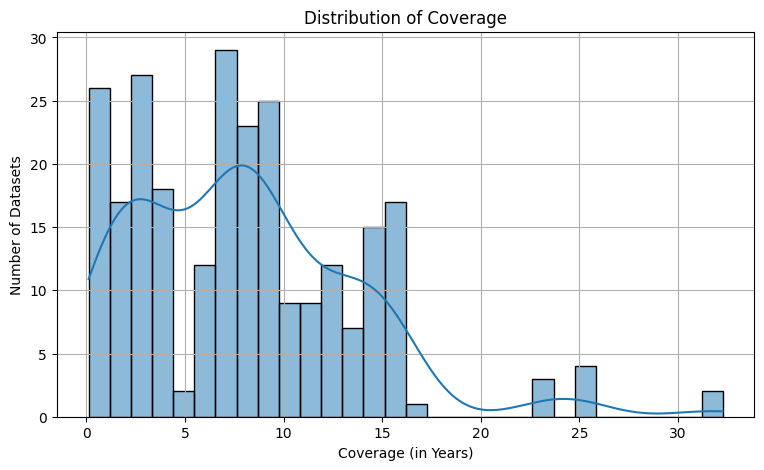

In [31]:
# Plot the distribution of dataset coverage with a Kernel Density Estimate (KDE) overlay.
gs_meta["coverage"] = (
    gs_meta["latest_available_time_utc"] - gs_meta["earliest_available_time_utc"]
).dt.days / 365.25
plt.figure(figsize=(9, 5))
sns.histplot(gs_meta["coverage"], bins=30, kde=True)
_make_plots(
    title="Distribution of Coverage",
    x_label="Coverage (in Years)",
    y_label="Number of Datasets",
    grid=True,
)

<a name='****5.-coverage-insights-by-frequency-and-snowflake-ingestion****'></a>
#### ****5. Coverage Insights by Frequency and Snowflake Ingestion****

The distribution of coverage durations across data frequencies reveals a strong concentration of datasets in the 1 hour and 5 mins categories, indicating a focus on high-resolution, time-sensitive data. This pattern suggests that the majority of the datasets are designed for real-time or near-real-time analytics, reflecting the importance of monitoring or responding to frequent, granular changes in data sources. Furthermore, most of these high-frequency datasets are successfully ingested into Snowflake, indicating that ingestion pipelines are optimized for high-frequency data streams. This prioritization likely stems from the increasing demand for up-to-date information and the ability to perform near-instantaneous analysis, which are critical for decision-making in operational environments. As a result, Snowflake's ability to efficiently handle and integrate high-frequency data is a key enabler for supporting analytics in time-critical contexts.

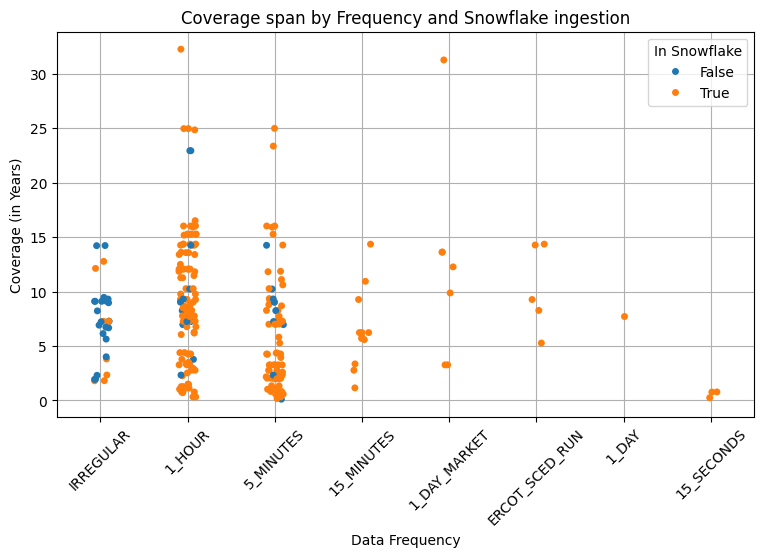

In [32]:
# Plot coverage span by data frequency, colored by Snowflake status.
plt.figure(figsize=(9, 5))
sns.stripplot(
    data=gs_meta,
    x="data_frequency",
    y="coverage",
    hue="is_in_snowflake",
    jitter=True,
)
_make_plots(
    title="Coverage span by Frequency and Snowflake ingestion",
    x_label="Data Frequency",
    y_label="Coverage (in Years)",
    legend="In Snowflake",
    x_rotation=45,
    grid=True,
)

<a name='****6.-snowflake-ingestion-insights-by-table-type****'></a>
#### ****6. Snowflake Ingestion Insights by Table Type****

```is_in_snowflake``` tells us what data is ready for the analytics team to use and what might still be missing from the system, while ```table_type``` distinguishes between how data is structured and consumed. Together, they highlight the current state of data integration and readiness across the warehouse. Understanding these gaps can inform ingestion priorities and surface potential blind spots in data accessibility.

The analysis of Snowflake ingestion shows some interesting patterns across different data types. All `materialized_view` entries are not ingested into Snowflake, which could mean they are either not needed in Snowflake or they are used in a different way. This might point to a gap in the data pipeline, where `materialized_view` datasets are not being properly integrated. On the other hand, around 95% of `table_view` entries are successfully ingested into Snowflake, showing that most structured data is already in the system. Around 90% of `view` entries are not ingested into Snowflake, which might mean that they are considered less important or are not yet ready for integration. It may be worth reviewing if some views should be added to Snowflake, especially if they are needed for analysis. Overall, while Snowflake is doing well with `table_view`, there’s room for improvement with `materialized_view` and `view`.

The limited Snowflake ingestion of `view` and `materialized_view` types may indicate that these datasets — often used for transformations, monitoring, or lightweight processing — are not yet considered part of the core analytics workflow. Their absence could restrict downstream accessibility or limit the scope of analysis. In contrast, the high ingestion rate of `table_view` entries suggests a focus on integrating well-structured, foundational datasets into Snowflake. This distinction highlights potential gaps in the data pipeline and raises the question of whether certain views should be incorporated to better support analytical needs.

**Note:** The following plot may be misleading if observed without context, as it could lead to incorrect conclusions. Since all `materialized_view` and most `view` entries are not ingested into Snowflake, one might mistakenly assume that the entries across this metadata are not ingested by Snowflake. In reality, around 85% of the entries fall under the `table_view`, and 95% of all `table_view` entries are ingested by Snowflake. Therefore, the majority of the data is successfully ingested into Snowflake, and this context is important for drawing accurate conclusions.

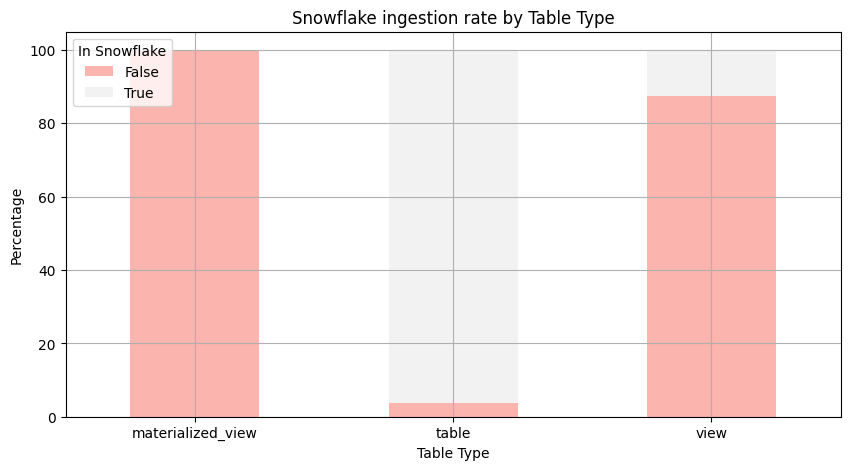

In [33]:
# Plot a normalized stacked bar chart of Snowflake ingestion by table type using a colormap.
sf_by_ttype = (
    pd.crosstab(
        gs_meta["table_type"], gs_meta["is_in_snowflake"], normalize="index"
    )
    * 100
)
sf_by_ttype.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="Pastel1")
_make_plots(
    title="Snowflake ingestion rate by Table Type",
    x_label="Table Type",
    y_label="Percentage",
    legend="In Snowflake",
    x_rotation=0,
    grid=True,
)

<a name='****7.-analysis-of-potentially-discontinued-series****'></a>
#### ****7. Analysis of Potentially Discontinued Series****

This plot visualizes the number of time series grouped by the number of days since their most recent data point ```latest_available_time_utc```. Time series with a high number of days since the last update may indicate that the datasets are potentially discontinued or inactive. A threshold of 60 days has been set to flag series that are potentially outdated, helping to identify datasets that may require further review for reactivation, archival, or removal. This approach provides a proactive way to monitor the health and relevance of time series in the data pipeline.

In [34]:
gs_meta["days_since_latest_data"] = (
    pd.Timestamp.utcnow() - gs_meta["latest_available_time_utc"]
).dt.days
discontinued_threshold = 60
discontinued_data = gs_meta[
    gs_meta["days_since_latest_data"] > discontinued_threshold
]
display(discontinued_data)

,id,name,description,earliest_available_time_utc,latest_available_time_utc,source,last_checked_time_utc,primary_key_columns,publish_time_column,time_index_column,...,number_of_rows_approximate,table_type,is_in_snowflake,data_frequency,source_url,publication_frequency,is_published,category,coverage,days_since_latest_data
6,caiso_curtailment_aggregated_hourly,CAISO Curtailment Aggregated Hourly,CAISO curtailment aggregated by wind and solar...,2016-06-30 07:00:00+00:00,2023-09-29 01:00:00+00:00,caiso,NaN,['interval_start_utc'],NaN,interval_start_utc,...,-1,view,False,1_HOUR,https://www.caiso.com/about/our-business/manag...,NaN,True,Renewables,7.244353,575.0
54,ercot_dam_energy_bid_awards_60_day,ERCOT DAM Energy Bid Awards 60 Day,"Day-ahead, hourly awards for offers to buy ene...",2013-01-01 06:00:00+00:00,2025-01-25 05:00:00+00:00,ercot,2025-04-09T15:04:36+00:00,"['interval_start_utc', 'settlement_point_name'...",NaN,interval_start_utc,...,47250192,table,True,1_HOUR,https://www.ercot.com/mp/data-products/data-pr...,NaN,True,Other,12.062971,91.0
55,ercot_dam_energy_bids_60_day,ERCOT DAM Energy Bids 60 Day,"Day-ahead, hourly bids to buy energy submitted...",2013-01-01 06:00:00+00:00,2025-01-25 05:00:00+00:00,ercot,2025-04-09T15:04:37+00:00,"['interval_start_utc', 'settlement_point_name'...",NaN,interval_start_utc,...,47219452,table,True,1_HOUR,https://www.ercot.com/mp/data-products/data-pr...,NaN,True,Other,12.062971,91.0
56,ercot_dam_energy_only_offer_awards_60_day,ERCOT DAM Energy Only Offer Awards 60 Day,"Day-ahead, hourly awards for offers to sell en...",2013-01-01 06:00:00+00:00,2025-01-25 05:00:00+00:00,ercot,2025-04-09T15:04:27+00:00,"['interval_start_utc', 'settlement_point_name'...",NaN,interval_start_utc,...,40429072,table,True,1_HOUR,https://www.ercot.com/mp/data-products/data-pr...,NaN,True,Prices,12.062971,91.0
57,ercot_dam_energy_only_offers_60_day,ERCOT DAM Energy Only Offers 60 Day,"Day-ahead, hourly offers to sell energy submit...",2013-01-01 06:00:00+00:00,2025-01-25 05:00:00+00:00,ercot,2025-04-09T15:04:27+00:00,"['interval_start_utc', 'settlement_point_name'...",NaN,interval_start_utc,...,40413416,table,True,1_HOUR,https://www.ercot.com/mp/data-products/data-pr...,NaN,True,Prices,12.062971,91.0
58,ercot_dam_gen_resource_60_day,ERCOT DAM Generation Resource 60 Day,DAM generation resource data. Published with 6...,2011-06-30 05:00:00+00:00,2025-01-25 05:00:00+00:00,ercot,2025-04-09T15:04:26+00:00,"['interval_start_utc', 'resource_name']",NaN,interval_start_utc,...,100989152,table,True,1_HOUR,https://www.ercot.com/mp/data-products/data-pr...,NaN,True,Other,13.574264,91.0
59,ercot_dam_gen_resource_as_offers_60_day,ERCOT DAM Generation Resource AS Offers 60 Day,Generation offers for ancillary services in ER...,2011-09-01 05:00:00+00:00,2025-01-25 05:00:00+00:00,ercot,2025-04-09T15:04:27+00:00,"['interval_start_utc', 'resource_name']",NaN,interval_start_utc,...,17508734,table,True,1_HOUR,https://www.ercot.com/mp/data-products/data-pr...,NaN,True,Other,13.401780,91.0
60,ercot_dam_load_resource_60_day,ERCOT DAM Load Resource 60 Day,DAM load resource data. Published with 60 day ...,2011-06-30 05:00:00+00:00,2025-01-25 05:00:00+00:00,ercot,2025-04-09T15:04:25+00:00,"['interval_start_utc', 'resource_name']",NaN,interval_start_utc,...,47557024,table,True,1_HOUR,https://www.ercot.com/mp/data-products/data-pr...,NaN,True,Energy Load,13.574264,91.0
61,ercot_dam_load_resource_as_offers_60_day,ERCOT DAM Load Resource AS Offers 60 Day,Load offers for ancillary services in ERCOT wi...,2011-09-01 05:00:00+00:00,2025-01-25 05:00:00+00:00,ercot,2025-04-09T15:04:25+00:00,"['interval_start_utc', 'resource_name']",NaN,interval_start_utc,...,23244380,table,True,1_HOUR,https://www.ercot.com/mp/data-products/data-pr...,NaN,True,Energy Load,13.401780,91.0
62,ercot_dam_ptp_obligation_bid_awards_60_day,ERCOT DAM PTP Obligation Bid Awards 60 Day,"Day-ahead, hourly, point-to-point (PTP) obliga...",2013-01-01 06:00:00+00:00,2025-01-25 05:00:00+

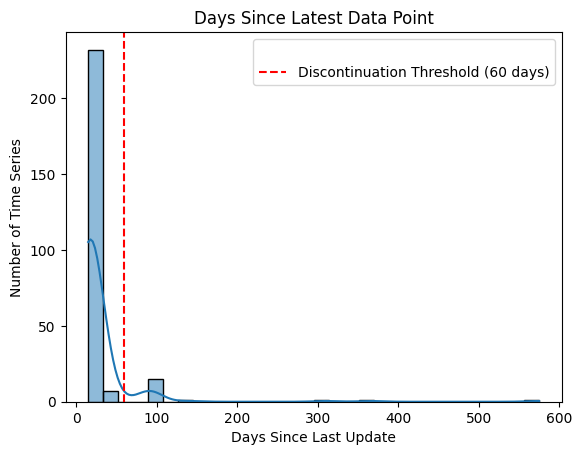

In [35]:
# Plot the distribution of days since the latest data point.
sns.histplot(gs_meta["days_since_latest_data"], bins=30, kde=True)
plt.axvline(
    discontinued_threshold,
    color="red",
    linestyle="--",
    label="Discontinuation Threshold (60 days)",
)
_make_plots(
    title="Days Since Latest Data Point",
    x_label="Days Since Last Update",
    y_label="Number of Time Series",
    legend=" ",
)

<a name='****8.-coverage-by-source-and-category****'></a>
#### ****8. Coverage by Source and Category****

The distribution of datasets across categories reveals underlying priorities in data collection practices within the energy sector. Load datasets overwhelmingly dominate the catalog, making up nearly 40% of the total, with ERCOT alone contributing about 25% of these entries. This suggests a strategic focus on understanding and forecasting demand patterns, likely because load forecasting is foundational for grid reliability and market operations. Price datasets form the second largest group, around 20%, highlighting the critical role of market pricing signals in operational decision-making and regulatory compliance. Meanwhile, categories like Renewables, Records, and Fuel Mix are moderately represented, each comprising between 7–10% of the data. Their presence reflects an emerging but still secondary emphasis on system transparency, environmental reporting, and evolving grid dynamics as the energy transition accelerates. The smaller size of categories such as Outages, Congestion, and Ancillary Services points to either challenges in consistent data availability across markets or a narrower operational scope for these datasets. Overall, the skewed distribution suggests that core operational metrics — particularly load and pricing — are prioritized for integration and standardization, while other areas are either developing or selectively collected depending on system maturity and regional market practices.

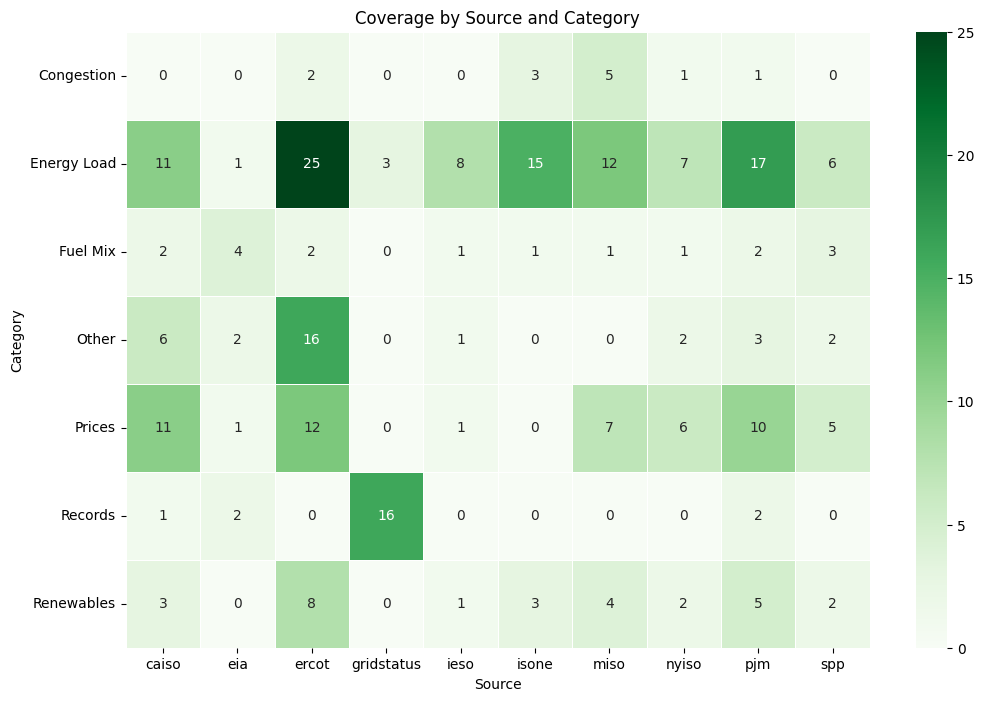

In [36]:
# Plot a heatmap to visualize the count of datasets across each source-category pair.
pivot_table = pd.pivot_table(
    gs_meta,
    values="id",
    index="category",
    columns="source",
    aggfunc="count",
    fill_value=0,
)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap="Greens", linewidths=0.5)
_make_plots(
    title="Coverage by Source and Category",
    x_label="Source",
    y_label="Category",
    y_rotation=0,
)